In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
sns.set_palette("husl")

behaviors_path = 'behaviors.tsv'
news_path = 'news.tsv'


# Load news data
news_df = pd.read_csv(news_path, sep='\t', header=None, 
                      names=['NewsID', 'Category', 'SubCategory', 'Title', 
                             'Abstract', 'URL', 'TitleEntities', 'AbstractEntities'])


try:
    behaviors_df = pd.read_csv(behaviors_path, sep='\t', header=None,
                               names=['ImpressionID', 'UserID', 'Time', 'History', 'Impressions'])
except MemoryError:
    print("Dataset too large, loading sample...")
    behaviors_df = pd.read_csv(behaviors_path, sep='\t', header=None,
                               names=['ImpressionID', 'UserID', 'Time', 'History', 'Impressions'],
                               nrows=200000)

In [3]:
print(f"News dataset shape: {news_df.shape}")
print(f"Behaviors dataset shape: {behaviors_df.shape}")

# Display basic information
print("       NEWS DATA - FIRST 3 ROWS")
print(news_df.head(3).to_string())
print(f"\nNews data columns: {list(news_df.columns)}")

print("       BEHAVIORS DATA - FIRST 3 ROWS")
print(behaviors_df.head(3).to_string())
print(f"\nBehaviors data columns: {list(behaviors_df.columns)}")


print("         DATASET BASIC INFO")

print("\n News Data Info:")
print(news_df.info())
print(f"\nUnique News IDs: {news_df['NewsID'].nunique()}")
print(f"Unique Categories: {news_df['Category'].nunique()}")
print(f"Unique SubCategories: {news_df['SubCategory'].nunique()}")

print("\n Behaviors Data Info:")
print(behaviors_df.info())
print(f"\nUnique Users: {behaviors_df['UserID'].nunique()}")
print(f"Unique Impression IDs: {behaviors_df['ImpressionID'].nunique()}")

News dataset shape: (101527, 8)
Behaviors dataset shape: (2232748, 5)
       NEWS DATA - FIRST 3 ROWS
   NewsID   Category               SubCategory                                                                   Title                                                                                                              Abstract                                            URL                                                                                                                                                                                                                                                                                                                                                                                                                                                                           TitleEntities                                                                                                                                               

In [4]:
print("          DATA QUALITY ANALYSIS")

# Check for missing values
print("\n MISSING VALUES ANALYSIS")
print("-" * 40)

# News data missing values
news_missing = news_df.isnull().sum()
print("News Data - Missing Values:")
for col, count in news_missing.items():
    if count > 0:
        print(f"  {col}: {count} ({count/len(news_df)*100:.2f}%)")
    else:
        print(f"  {col}: No missing values")

# Behaviors data missing values
behaviors_missing = behaviors_df.isnull().sum()
print("\nBehaviors Data - Missing Values:")
for col, count in behaviors_missing.items():
    if count > 0:
        print(f"  {col}: {count} ({count/len(behaviors_df)*100:.2f}%)")
    else:
        print(f"  {col}: No missing values")

# Check for empty strings
print("\n EMPTY STRING ANALYSIS")
print("-" * 40)

empty_titles = (news_df['Title'].astype(str).str.strip() == '').sum()
empty_abstracts = (news_df['Abstract'].astype(str).str.strip() == '').sum()
print(f"Empty Titles: {empty_titles} ({empty_titles/len(news_df)*100:.2f}%)")
print(f"Empty Abstracts: {empty_abstracts} ({empty_abstracts/len(news_df)*100:.2f}%)")

# Check for duplicates
print("\n DUPLICATE ANALYSIS")
print("-" * 40)
print(f"Duplicate News IDs: {news_df['NewsID'].duplicated().sum()}")
print(f"Duplicate Titles: {news_df['Title'].duplicated().sum()}")
print(f"Duplicate Behavior Rows: {behaviors_df.duplicated().sum()}")

          DATA QUALITY ANALYSIS

 MISSING VALUES ANALYSIS
----------------------------------------
News Data - Missing Values:
  NewsID: No missing values
  Category: No missing values
  SubCategory: No missing values
  Title: No missing values
  Abstract: 5415 (5.33%)
  URL: No missing values
  TitleEntities: 3 (0.00%)
  AbstractEntities: 6 (0.01%)

Behaviors Data - Missing Values:
  ImpressionID: No missing values
  UserID: No missing values
  Time: No missing values
  History: 46065 (2.06%)
  Impressions: No missing values

 EMPTY STRING ANALYSIS
----------------------------------------
Empty Titles: 0 (0.00%)
Empty Abstracts: 0 (0.00%)

 DUPLICATE ANALYSIS
----------------------------------------
Duplicate News IDs: 0
Duplicate Titles: 3139
Duplicate Behavior Rows: 0


 NEWS CONTENT ANALYSIS

 TEXT LENGTH ANALYSIS
----------------------------------------
Text Statistics Summary:
             Metric       Mean  Median        Std  Min  Max
   Title Characters  66.014883    64.0  19.281436   11  554
        Title Words  10.665518    10.0   3.263087    1   95
Abstract Characters 216.630089   149.0 160.034092    1 2603
     Abstract Words  36.293400    25.0  26.826607    1  474


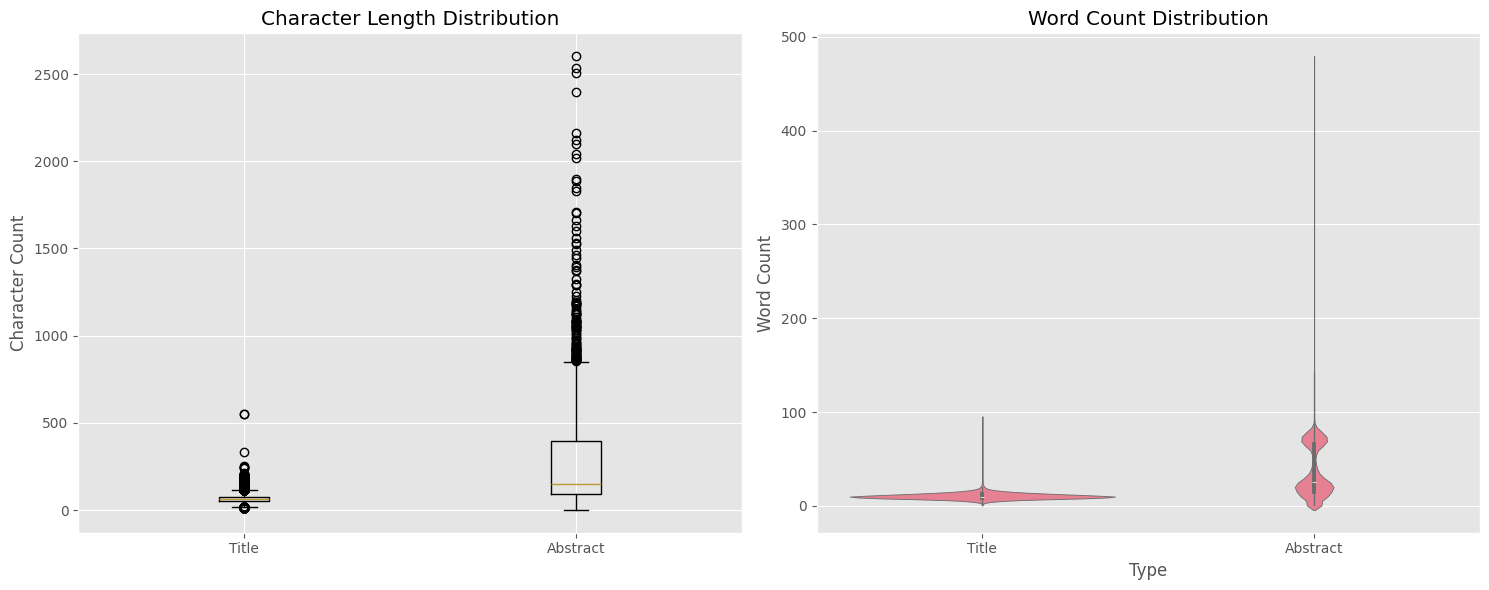


 CATEGORY DISTRIBUTION ANALYSIS
----------------------------------------
Total Unique Categories: 18
Total Unique SubCategories: 285

Top 10 Categories by Count:
 1. sports              :  32020 articles (31.5%)
 2. news                :  30478 articles (30.0%)
 3. finance             :   5916 articles (5.8%)
 4. travel              :   4955 articles (4.9%)
 5. lifestyle           :   4570 articles (4.5%)
 6. video               :   4569 articles (4.5%)
 7. foodanddrink        :   4418 articles (4.4%)
 8. weather             :   4255 articles (4.2%)
 9. autos               :   3071 articles (3.0%)
10. health              :   2929 articles (2.9%)

Top 10 SubCategories by Count:
 1. newsus              :  14467 articles (14.2%)
 2. football_nfl        :  11813 articles (11.6%)
 3. newspolitics        :   5145 articles (5.1%)
 4. weathertopstories   :   4253 articles (4.2%)
 5. newscrime           :   3676 articles (3.6%)
 6. baseball_mlb        :   3617 articles (3.6%)
 7. football_ncaa

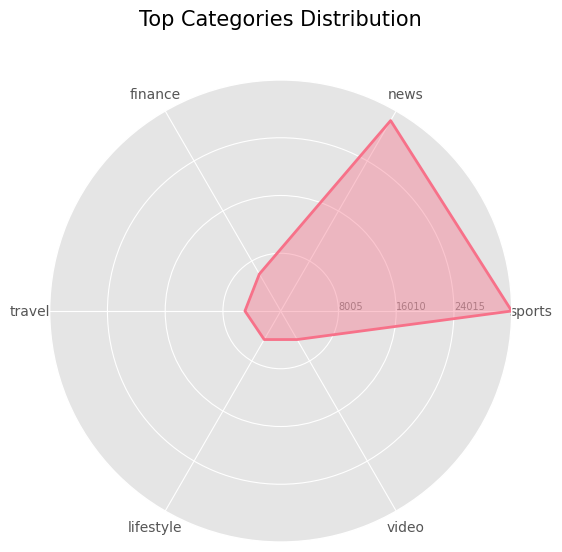

<Figure size 640x480 with 0 Axes>


 CATEGORY-SUBCATEGORY HIERARCHY
----------------------------------------

Categories with most subcategories:
 1. lifestyle           : 53 subcategories
   Sample subcategories: lifestyleroyals, lifestylelovesex, lifestylepetsanimals
 2. news                : 38 subcategories
   Sample subcategories: newsscienceandtechnology, newsworld, newspolitics
 3. sports              : 34 subcategories
   Sample subcategories: football_nfl, more_sports, golf
 4. finance             : 33 subcategories
   Sample subcategories: finance-insurance, finance-real-estate, financenews
 5. autos               : 25 subcategories
   Sample subcategories: autosenthusiasts, autossports, autossuvs
 6. health              : 23 subcategories
   Sample subcategories: weightloss, medical, voices
 7. foodanddrink        : 16 subcategories
   Sample subcategories: recipes, newstrends, quickandeasy
 8. travel              : 16 subcategories
   Sample subcategories: travelarticle, traveltripideas, travelnews
 9. enter

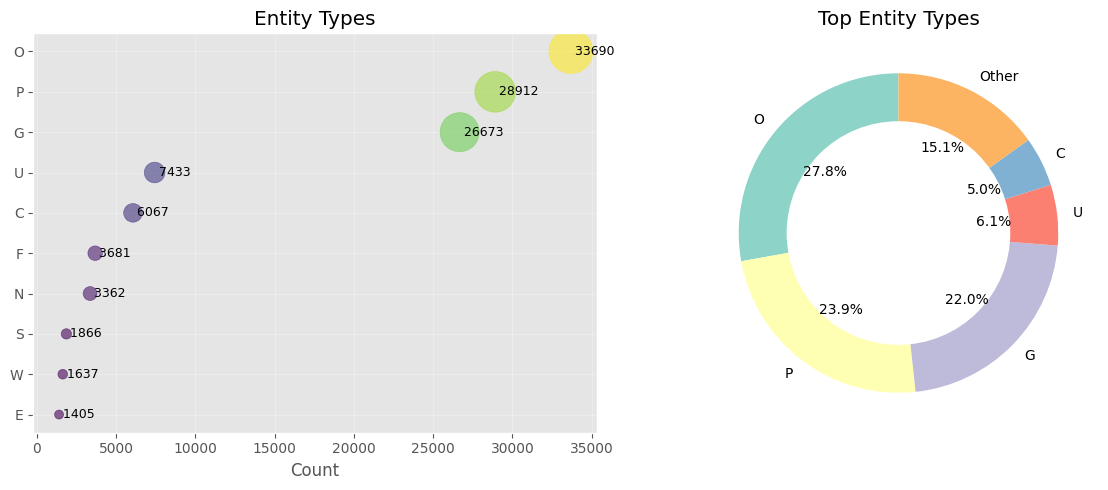

In [5]:
print(" NEWS CONTENT ANALYSIS")
# Text length analysis
print("\n TEXT LENGTH ANALYSIS")
print("-" * 40)

news_df['Title_Length'] = news_df['Title'].astype(str).apply(len)
news_df['Abstract_Length'] = news_df['Abstract'].astype(str).apply(len)
news_df['Title_Word_Count'] = news_df['Title'].astype(str).apply(lambda x: len(str(x).split()))
news_df['Abstract_Word_Count'] = news_df['Abstract'].astype(str).apply(lambda x: len(str(x).split()))

# Display text statistics
text_stats = pd.DataFrame({
    'Metric': ['Title Characters', 'Title Words', 'Abstract Characters', 'Abstract Words'],
    'Mean': [news_df['Title_Length'].mean(), news_df['Title_Word_Count'].mean(),
             news_df['Abstract_Length'].mean(), news_df['Abstract_Word_Count'].mean()],
    'Median': [news_df['Title_Length'].median(), news_df['Title_Word_Count'].median(),
               news_df['Abstract_Length'].median(), news_df['Abstract_Word_Count'].median()],
    'Std': [news_df['Title_Length'].std(), news_df['Title_Word_Count'].std(),
            news_df['Abstract_Length'].std(), news_df['Abstract_Word_Count'].std()],
    'Min': [news_df['Title_Length'].min(), news_df['Title_Word_Count'].min(),
            news_df['Abstract_Length'].min(), news_df['Abstract_Word_Count'].min()],
    'Max': [news_df['Title_Length'].max(), news_df['Title_Word_Count'].max(),
            news_df['Abstract_Length'].max(), news_df['Abstract_Word_Count'].max()]
})

print("Text Statistics Summary:")
print(text_stats.to_string(index=False))

# Visualizations for text lengths
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Box plots for text lengths
axes[0].boxplot([news_df['Title_Length'].dropna(), 
                    news_df['Abstract_Length'].dropna()], 
                   labels=['Title', 'Abstract'])
axes[0].set_title('Character Length Distribution')
axes[0].set_ylabel('Character Count')

# Violin plot for word counts
import seaborn as sns
title_words = news_df['Title_Word_Count'].dropna()
abstract_words = news_df['Abstract_Word_Count'].dropna()
data_for_violin = pd.DataFrame({
    'Word Count': pd.concat([title_words, abstract_words]),
    'Type': ['Title'] * len(title_words) + ['Abstract'] * len(abstract_words)
})
sns.violinplot(x='Type', y='Word Count', data=data_for_violin, ax=axes[1])
axes[1].set_title('Word Count Distribution')

plt.tight_layout()
plt.show()

# Category Analysis
print("\n CATEGORY DISTRIBUTION ANALYSIS")
print("-" * 40)

# Top categories
top_categories = news_df['Category'].value_counts().head(15)
top_subcategories = news_df['SubCategory'].value_counts().head(15)

print(f"Total Unique Categories: {news_df['Category'].nunique()}")
print(f"Total Unique SubCategories: {news_df['SubCategory'].nunique()}")

print("\nTop 10 Categories by Count:")
for i, (category, count) in enumerate(top_categories.head(10).items(), 1):
    print(f"{i:2d}. {category:20s}: {count:6d} articles ({count/len(news_df)*100:.1f}%)")

print("\nTop 10 SubCategories by Count:")
for i, (subcat, count) in enumerate(top_subcategories.head(10).items(), 1):
    print(f"{i:2d}. {subcat:20s}: {count:6d} articles ({count/len(news_df)*100:.1f}%)")


# Radar chart for top categories
from math import pi
# Create a separate figure for radar chart
radar_fig = plt.figure(figsize=(6, 6))
radar_ax = radar_fig.add_subplot(111, projection='polar')

top_6_categories = top_categories.head(6)
categories = list(top_6_categories.index)
values = list(top_6_categories.values)

# Number of variables
N = len(categories)

# What will be the angle of each axis in the plot
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]  # Close the loop

# Plot data
values += values[:1]
radar_ax.plot(angles, values, linewidth=2, linestyle='solid')
radar_ax.fill(angles, values, alpha=0.4)

# Draw axis lines for each angle and label
radar_ax.set_xticks(angles[:-1])
radar_ax.set_xticklabels([cat[:15] + '...' if len(cat) > 15 else cat for cat in categories])

# Draw ylabels
radar_ax.set_rlabel_position(0)
plt.yticks([max(values)/4, max(values)/2, 3*max(values)/4], 
           [str(int(max(values)/4)), str(int(max(values)/2)), str(int(3*max(values)/4))], 
           color="grey", size=7)
radar_ax.set_ylim(0, max(values))

plt.title('Top Categories Distribution', size=15, y=1.1)
plt.show()

# Network graph style visualization for categories and subcategories
axes[0].axis('off')
axes[0].set_title('Category-Subcategory Network', fontsize=12, pad=20)

# Get top 3 categories and their top subcategories
top_3_cats = top_categories.head(3).index.tolist()

# Draw nodes and connections
node_positions = {}
cat_nodes = []
subcat_nodes = []

# Position category nodes in a circle
center_x, center_y = 0.5, 0.5
radius = 0.3

for i, cat in enumerate(top_3_cats):
    angle = 2 * pi * i / len(top_3_cats)
    x = center_x + radius * np.cos(angle)
    y = center_y + radius * np.sin(angle)
    
    # Draw category node
    circle = plt.Circle((x, y), 0.05, color=plt.cm.Set2(i), alpha=0.8)
    axes[0].add_patch(circle)
    axes[0].text(x, y - 0.07, cat[:10] + '...', 
                   fontsize=8, ha='center', fontweight='bold')
    node_positions[cat] = (x, y)
    
    # Get top subcategories for this category
    subcats = news_df[news_df['Category'] == cat]['SubCategory'].value_counts().head(3)
    
    # Position subcategory nodes around the category
    for j, (subcat, count) in enumerate(subcats.items()):
        sub_angle = angle - pi/6 + j * pi/6
        sub_x = x + 0.2 * np.cos(sub_angle)
        sub_y = y + 0.2 * np.sin(sub_angle)
        
        # Draw connection line
        axes[0].plot([x, sub_x], [y, sub_y], 'gray', alpha=0.5, linewidth=0.5)
        
        # Draw subcategory node
        circle = plt.Circle((sub_x, sub_y), 0.02, color=plt.cm.Set2(i+3), alpha=0.6)
        axes[0].add_patch(circle)
        axes[0].text(sub_x, sub_y - 0.04, subcat[:8] + '...', 
                       fontsize=6, ha='center')

axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)

plt.tight_layout()
plt.show()

# Category-SubCategory hierarchy
print("\n CATEGORY-SUBCATEGORY HIERARCHY")
print("-" * 40)
category_hierarchy = news_df.groupby('Category')['SubCategory'].nunique().sort_values(ascending=False)

print("\nCategories with most subcategories:")
for i, (cat, count) in enumerate(category_hierarchy.head(10).items(), 1):
    subcats = news_df[news_df['Category'] == cat]['SubCategory'].unique()[:5]
    print(f"{i:2d}. {cat:20s}: {count:2d} subcategories")
    if len(subcats) > 0:
        print(f"   Sample subcategories: {', '.join(subcats[:3])}")

# Entity Analysis
print("\n ENTITY ANALYSIS")
print("-" * 40)

def parse_entities(entity_string):
    """Parse entity JSON string safely"""
    try:
        if pd.isna(entity_string) or entity_string in ['[]', '', 'None', 'nan']:
            return []
        return json.loads(entity_string)
    except:
        return []

# Parse entities
news_df['Title_Entities_Parsed'] = news_df['TitleEntities'].apply(parse_entities)
news_df['Abstract_Entities_Parsed'] = news_df['AbstractEntities'].apply(parse_entities)

# Count entities
news_df['Title_Entity_Count'] = news_df['Title_Entities_Parsed'].apply(len)
news_df['Abstract_Entity_Count'] = news_df['Abstract_Entities_Parsed'].apply(len)

print(f"Articles with title entities: {(news_df['Title_Entity_Count'] > 0).sum()} ({(news_df['Title_Entity_Count'] > 0).sum()/len(news_df)*100:.1f}%)")
print(f"Articles with abstract entities: {(news_df['Abstract_Entity_Count'] > 0).sum()} ({(news_df['Abstract_Entity_Count'] > 0).sum()/len(news_df)*100:.1f}%)")
print(f"Average title entities per article: {news_df['Title_Entity_Count'].mean():.2f}")
print(f"Average abstract entities per article: {news_df['Abstract_Entity_Count'].mean():.2f}")

# Analyze entity types if entities exist
all_entities = []
for entities in news_df['Title_Entities_Parsed']:
    for entity in entities:
        if isinstance(entity, dict):
            all_entities.append(entity.get('Type', 'Unknown'))

if all_entities:
    entity_counts = Counter(all_entities)
    print("\nTop 10 Entity Types in Titles:")
    for i, (etype, count) in enumerate(entity_counts.most_common(10), 1):
        print(f"{i:2d}. {etype:15s}: {count:6d}")
    
    # Plot enhanced entity type distribution
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Word cloud style frequency visualization
    top_entity_types = dict(entity_counts.most_common(10))
    
    # Create bubble chart for entity types
    entity_names = list(top_entity_types.keys())[::-1]
    entity_counts_list = list(top_entity_types.values())[::-1]
    
    y_pos = np.arange(len(entity_names))
    bubble_sizes = [count / max(entity_counts_list) * 1000 for count in entity_counts_list]
    
    scatter = axes[0].scatter(entity_counts_list, y_pos, s=bubble_sizes, 
                             alpha=0.6, c=entity_counts_list, cmap='viridis')
    axes[0].set_yticks(y_pos)
    axes[0].set_yticklabels(entity_names)
    axes[0].set_xlabel('Count')
    axes[0].set_title('Entity Types')
    axes[0].grid(True, alpha=0.3)
    
    # Add count labels to bubbles
    for i, (count, y) in enumerate(zip(entity_counts_list, y_pos)):
        axes[0].text(count, y, f' {count}', va='center', fontsize=9)
    
    # Donut chart for entity distribution
    top_5_entities = dict(entity_counts.most_common(5))
    other_count = sum(entity_counts.values()) - sum(top_5_entities.values())
    
    if other_count > 0:
        top_5_entities['Other'] = other_count
    
    wedges, texts, autotexts = axes[1].pie(top_5_entities.values(), 
                                          labels=top_5_entities.keys(),
                                          autopct='%1.1f%%',
                                          startangle=90,
                                          colors=plt.cm.Set3(np.arange(len(top_5_entities))))
    
    # Draw circle at center for donut chart
    centre_circle = plt.Circle((0,0),0.70,fc='white')
    axes[1].add_patch(centre_circle)
    axes[1].set_title('Top Entity Types')
    
    plt.tight_layout()
    plt.show()

  The box and violin plots comparing titles and abstracts reveal a clear structural difference in news content: titles are short, consistent, and tightly distributed, while abstracts are longer and far more variable. This pattern reflects editorial constraints on headlines and the optional, free‑form nature of abstracts, which provide richer semantic detail but introduce greater variability for text modeling.
  The radar chart of top categories shows a strong imbalance, with news and sports dominating the dataset and categories like finance, lifestyle, travel, and video appearing far less frequently. This skew mirrors real-world publishing priorities and introduces challenges for models that must learn from both high‑volume and low‑volume categories.
  The entity-type donut chart shows that organizations, persons, and geopolitical entities make up the majority of extracted entities, while concepts and miscellaneous types appear less frequently. This distribution highlights the knowledge-rich nature of news content and supports the use of entity-aware or knowledge-graph–enhanced recommendation models.

USER BEHAVIOR ANALYSIS

Total impressions analyzed: 83,507,374
Total clicks recorded: 3,383,656
Overall CTR: 0.0405 (4.05%)

 USER ACTIVITY ANALYSIS
----------------------------------------
Total unique users: 711,222
Average history length per user: 103.5
Average impressions per user: 117.4
Average clicks per user: 4.8
Average user CTR: 0.1142

 Cold Start Users (no history): 46,065 (2.1% of sessions)
 Cold start user CTR: 0.1065
 Regular user CTR: 0.1083
 CTR difference: 0.0018


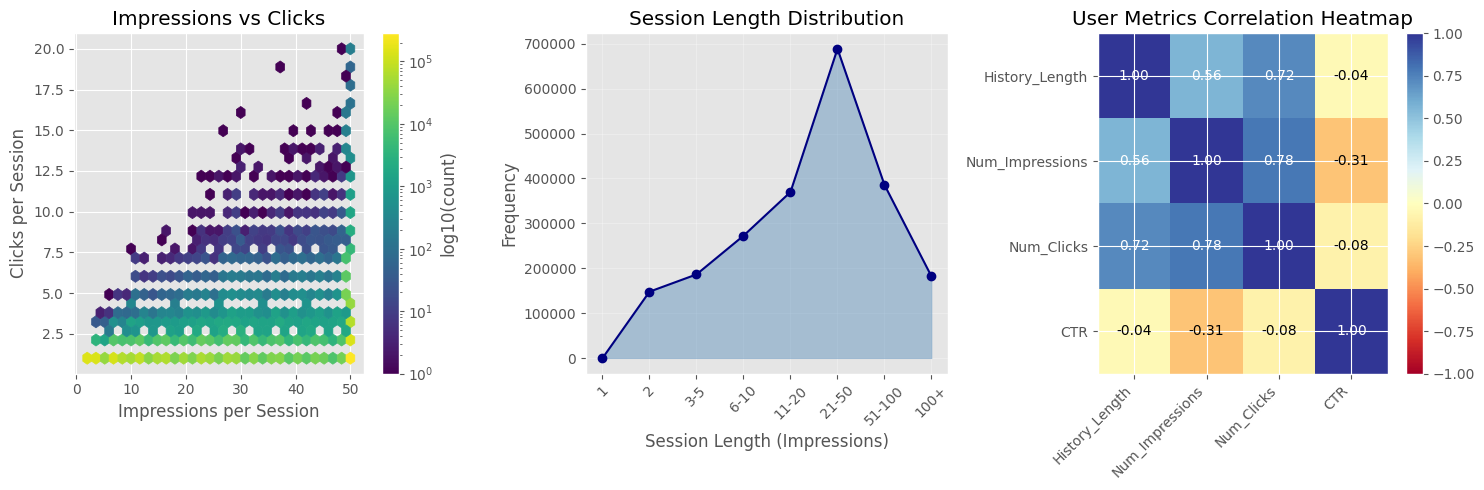


 SESSION LENGTH ANALYSIS
----------------------------------------
Session Length Statistics:
                         Session_Count  Avg_CTR  Avg_Clicks  Percentage
Session_Length_Category                                                
1-5                             334404   0.3702      1.0149        15.0
6-10                            272483   0.1448      1.1218        12.2
11-20                           369782   0.0831      1.2145        16.6
21-50                           688508   0.0481      1.5184        30.8
50+                             567571   0.0259      2.1919        25.4

TEMPORAL ANALYSIS
----------------------------------------


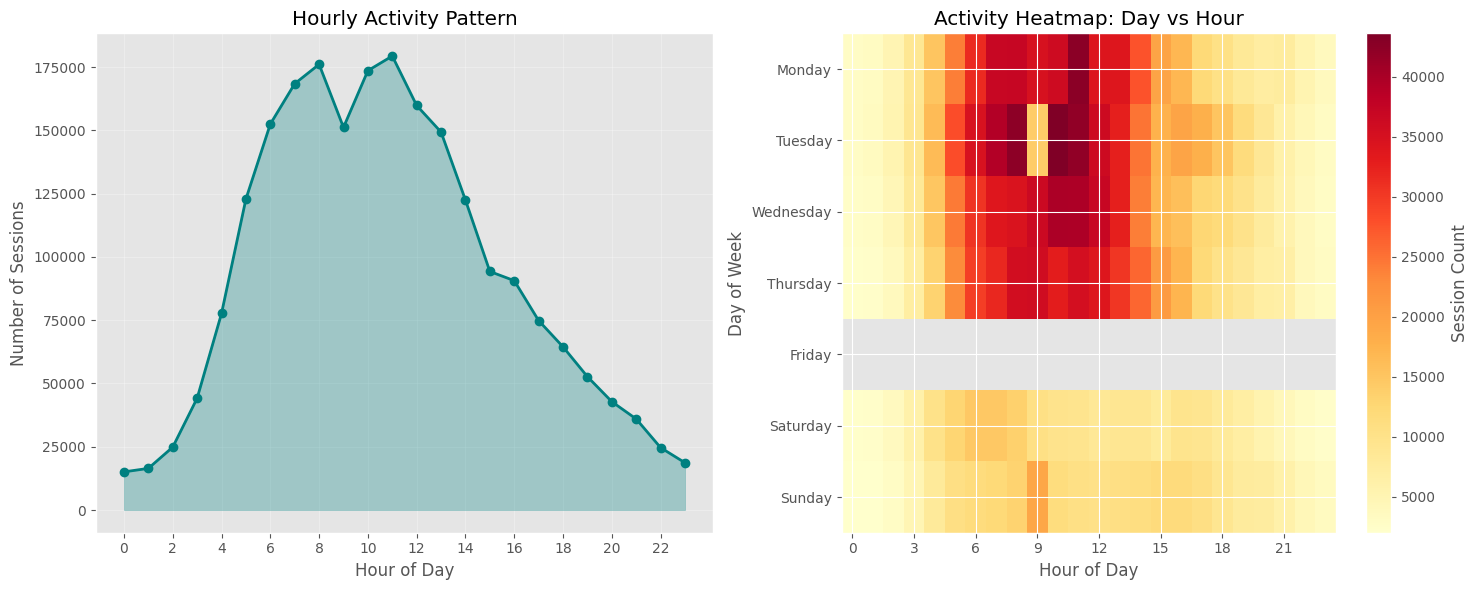

- Peak activity hour: 11:00 (179,368 sessions)
- Lowest activity hour: 0:00 (15,071 sessions)
- Most active day: Tuesday (478,375.0 sessions)
- Best CTR hour: 21:00 (0.1193)


In [6]:
print("=" * 60)
print("USER BEHAVIOR ANALYSIS")
print("=" * 60)

# Ensure strings
behaviors_df['Impressions'] = behaviors_df['Impressions'].fillna('')
behaviors_df['History'] = behaviors_df['History'].fillna('')

# Number of impressions per session
behaviors_df['Num_Impressions'] = (
    behaviors_df['Impressions'].str.count(' ') + 1
)
behaviors_df.loc[behaviors_df['Impressions'] == '', 'Num_Impressions'] = 0

# Number of clicks per session (count "-1")
behaviors_df['Num_Clicks'] = behaviors_df['Impressions'].str.count('-1')

# CTR (safe division)
behaviors_df['CTR'] = (
    behaviors_df['Num_Clicks'] / behaviors_df['Num_Impressions'].replace(0, np.nan)
).fillna(0)

# History length
behaviors_df['History_Length'] = (
    behaviors_df['History']
    .str.strip()
    .replace('', np.nan)
    .str.split()
    .str.len()
    .fillna(0)
    .astype(int)
)
behaviors_df.loc[behaviors_df['History'] == '', 'History_Length'] = 0

# BASIC METRICS
total_impressions = behaviors_df['Num_Impressions'].sum()
total_clicks = behaviors_df['Num_Clicks'].sum()
overall_ctr = total_clicks / total_impressions if total_impressions > 0 else 0

print(f"\nTotal impressions analyzed: {total_impressions:,}")
print(f"Total clicks recorded: {total_clicks:,}")
print(f"Overall CTR: {overall_ctr:.4f} ({overall_ctr*100:.2f}%)")

# USER ACTIVITY ANALYSIS
print("\n USER ACTIVITY ANALYSIS")
print("-" * 40)

user_stats = behaviors_df.groupby('UserID', as_index=False).agg(
    History_Length=('History_Length', 'sum'),
    Num_Impressions=('Num_Impressions', 'sum'),
    Num_Clicks=('Num_Clicks', 'sum'),
    CTR=('CTR', 'mean')
)

print(f"Total unique users: {len(user_stats):,}")
print(f"Average history length per user: {user_stats['History_Length'].mean():.1f}")
print(f"Average impressions per user: {user_stats['Num_Impressions'].mean():.1f}")
print(f"Average clicks per user: {user_stats['Num_Clicks'].mean():.1f}")
print(f"Average user CTR: {user_stats['CTR'].mean():.4f}")

# Cold start analysis
cold_start_users = behaviors_df[behaviors_df['History_Length'] == 0]
print(f"\n Cold Start Users (no history): {len(cold_start_users):,} ({len(cold_start_users)/len(behaviors_df)*100:.1f}% of sessions)")

if len(cold_start_users) > 0:
    cold_start_ctr = cold_start_users['CTR'].mean()
    regular_users_ctr = behaviors_df[behaviors_df['History_Length'] > 0]['CTR'].mean()
    print(f" Cold start user CTR: {cold_start_ctr:.4f}")
    print(f" Regular user CTR: {regular_users_ctr:.4f}")
    print(f" CTR difference: {abs(cold_start_ctr - regular_users_ctr):.4f}")

# Visualize enhanced user activity distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Hexbin plot for impressions vs clicks
hb = axes[0].hexbin(behaviors_df['Num_Impressions'].clip(0, 50), 
                       behaviors_df['Num_Clicks'].clip(0, 20), 
                       gridsize=30, cmap='viridis', bins='log')
axes[0].set_xlabel('Impressions per Session')
axes[0].set_ylabel('Clicks per Session')
axes[0].set_title('Impressions vs Clicks')
plt.colorbar(hb, ax=axes[0], label='log10(count)')

# Stacked area chart for session length distribution
session_lengths = behaviors_df['Num_Impressions']
length_bins = pd.cut(session_lengths, 
                     bins=[0, 1, 2, 5, 10, 20, 50, 100, 1000],
                     labels=['1', '2', '3-5', '6-10', '11-20', '21-50', '51-100', '100+'])
length_dist = length_bins.value_counts().sort_index()

axes[1].fill_between(range(len(length_dist)), length_dist.values, alpha=0.4, color='steelblue')
axes[1].plot(range(len(length_dist)), length_dist.values, marker='o', color='navy')
axes[1].set_xticks(range(len(length_dist)))
axes[1].set_xticklabels(length_dist.index, rotation=45)
axes[1].set_xlabel('Session Length (Impressions)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Session Length Distribution')
axes[1].grid(True, alpha=0.3)

# Heatmap of correlations between user metrics
user_corr = user_stats[['History_Length', 'Num_Impressions', 'Num_Clicks', 'CTR']].corr()
im = axes[2].imshow(user_corr, cmap='RdYlBu', aspect='auto', vmin=-1, vmax=1)
axes[2].set_title('User Metrics Correlation Heatmap')
axes[2].set_xticks(range(len(user_corr.columns)))
axes[2].set_yticks(range(len(user_corr.columns)))
axes[2].set_xticklabels(user_corr.columns, rotation=45, ha='right')
axes[2].set_yticklabels(user_corr.columns)

# Add correlation values
for i in range(len(user_corr.columns)):
    for j in range(len(user_corr.columns)):
        axes[2].text(j, i, f'{user_corr.iloc[i, j]:.2f}',
                       ha='center', va='center', 
                       color='white' if abs(user_corr.iloc[i, j]) > 0.5 else 'black')

plt.colorbar(im, ax=axes[2])
plt.tight_layout()
plt.show()

# Session length analysis
print("\n SESSION LENGTH ANALYSIS")
print("-" * 40)

behaviors_df['Session_Length_Category'] = pd.cut(
    behaviors_df['Num_Impressions'],
    bins=[0, 5, 10, 20, 50, float('inf')],
    labels=['1-5', '6-10', '11-20', '21-50', '50+']
)

session_stats = behaviors_df.groupby('Session_Length_Category').agg({
    'ImpressionID': 'count',
    'CTR': 'mean',
    'Num_Clicks': 'mean'
}).round(4)

session_stats.columns = ['Session_Count', 'Avg_CTR', 'Avg_Clicks']
session_stats['Percentage'] = (session_stats['Session_Count'] / session_stats['Session_Count'].sum() * 100).round(1)

print("Session Length Statistics:")
print(session_stats.to_string())

# Temporal Analysis
print("\nTEMPORAL ANALYSIS")
print("-" * 40)

try:
    behaviors_df['Time_Parsed'] = pd.to_datetime(behaviors_df['Time'], 
                                                 format='%m/%d/%Y %I:%M:%S %p', 
                                                 errors='coerce')
    behaviors_df['Hour'] = behaviors_df['Time_Parsed'].dt.hour
    behaviors_df['DayOfWeek'] = behaviors_df['Time_Parsed'].dt.day_name()
    behaviors_df['Date'] = behaviors_df['Time_Parsed'].dt.date
    
    has_time_data = True
    
    # Hourly activity
    hourly_activity = behaviors_df['Hour'].value_counts().sort_index()
    
    # Day of week activity
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    day_activity = behaviors_df['DayOfWeek'].value_counts()
    day_activity = day_activity.reindex(day_order)
    
    # CTR by hour
    ctr_by_hour = behaviors_df.groupby('Hour')['CTR'].mean()
    
    # Daily trend
    daily_activity = behaviors_df.groupby('Date').size()
    
    # Visualize enhanced temporal patterns
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Area chart for hourly activity
    axes[0].fill_between(hourly_activity.index, hourly_activity.values, 
                           alpha=0.3, color='teal')
    axes[0].plot(hourly_activity.index, hourly_activity.values, 
                   marker='o', color='teal', linewidth=2)
    axes[0].set_title('Hourly Activity Pattern')
    axes[0].set_xlabel('Hour of Day')
    axes[0].set_ylabel('Number of Sessions')
    axes[0].set_xticks(range(0, 24, 2))
    axes[0].grid(True, alpha=0.3)
    
    # Heatmap for day-hour activity
    # Create pivot table for heatmap
    behaviors_df['Hour_Bin'] = pd.cut(behaviors_df['Hour'], bins=24, labels=range(24))
    day_hour_pivot = behaviors_df.pivot_table(index='DayOfWeek', 
                                             columns='Hour', 
                                             values='ImpressionID', 
                                             aggfunc='count')
    day_hour_pivot = day_hour_pivot.reindex(day_order)
    
    im = axes[1].imshow(day_hour_pivot, aspect='auto', cmap='YlOrRd')
    axes[1].set_title('Activity Heatmap: Day vs Hour')
    axes[1].set_xlabel('Hour of Day')
    axes[1].set_ylabel('Day of Week')
    axes[1].set_xticks(range(0, 24, 3))
    axes[1].set_yticks(range(len(day_order)))
    axes[1].set_yticklabels(day_order)
    plt.colorbar(im, ax=axes[1], label='Session Count')
    
    plt.tight_layout()
    plt.show()
    
    # Peak analysis
    peak_hour = hourly_activity.idxmax()
    peak_activity = hourly_activity.max()
    low_hour = hourly_activity.idxmin()
    low_activity = hourly_activity.min()
    peak_day = day_activity.idxmax()
    peak_day_count = day_activity.max()
    best_ctr_hour = ctr_by_hour.idxmax()
    best_ctr = ctr_by_hour.max()
    
    print(f"- Peak activity hour: {peak_hour}:00 ({peak_activity:,} sessions)")
    print(f"- Lowest activity hour: {low_hour}:00 ({low_activity:,} sessions)")
    print(f"- Most active day: {peak_day} ({peak_day_count:,} sessions)")
    print(f"- Best CTR hour: {best_ctr_hour}:00 ({best_ctr:.4f})")
    
except Exception as e:
    print(f"Could not parse time data: {e}")
    has_time_data = False


  The impressions–clicks hexbin plot shows that sessions with more impressions generally lead to more clicks, though the relationship tapers off as exposure increases, reflecting diminishing user attention. The session length distribution highlights that most sessions fall in the 21–50 impression range, with very short and very long sessions being less common. The correlation heatmap confirms that impressions, clicks, and history length are strongly related, while CTR remains largely independent, indicating that higher activity does not necessarily translate into higher engagement efficiency.
  User behavior analysis reveals that shorter sessions (1–5 impressions) yield the highest CTR (0.37), while longer sessions (50+ impressions) generate more clicks but lower CTR, indicating reduced selectivity. Activity peaks at 11:00 AM, with Tuesday being the most active day, yet the highest CTR occurs at 9:00 PM, suggesting users browse more during the day but engage more decisively in the evening. These patterns highlight the importance of session-aware and time-sensitive recommendation strategies.

INTEGRATED NEWS-BEHAVIOR ANALYSIS
Extracted 3,383,656 click events

 CATEGORY ENGAGEMENT ANALYSIS
----------------------------------------

Top 10 Categories by Engagement (Clicks per Article):
 1. entertainment       : 182.109 clicks/article (152,425 clicks, 837 articles)
 2. music               : 178.648 clicks/article (225,633 clicks, 1,263 articles)
 3. tv                  : 157.127 clicks/article (207,879 clicks, 1,323 articles)
 4. lifestyle           : 83.650 clicks/article (382,282 clicks, 4,570 articles)
 5. movies              : 73.806 clicks/article (60,152 clicks, 815 articles)
 6. health              : 54.209 clicks/article (158,779 clicks, 2,929 articles)
 7. finance             : 49.455 clicks/article (292,574 clicks, 5,916 articles)
 8. foodanddrink        : 35.839 clicks/article (158,336 clicks, 4,418 articles)
 9. autos               : 34.408 clicks/article (105,667 clicks, 3,071 articles)
10. news                : 32.700 clicks/article (996,645 clicks, 30,478 article

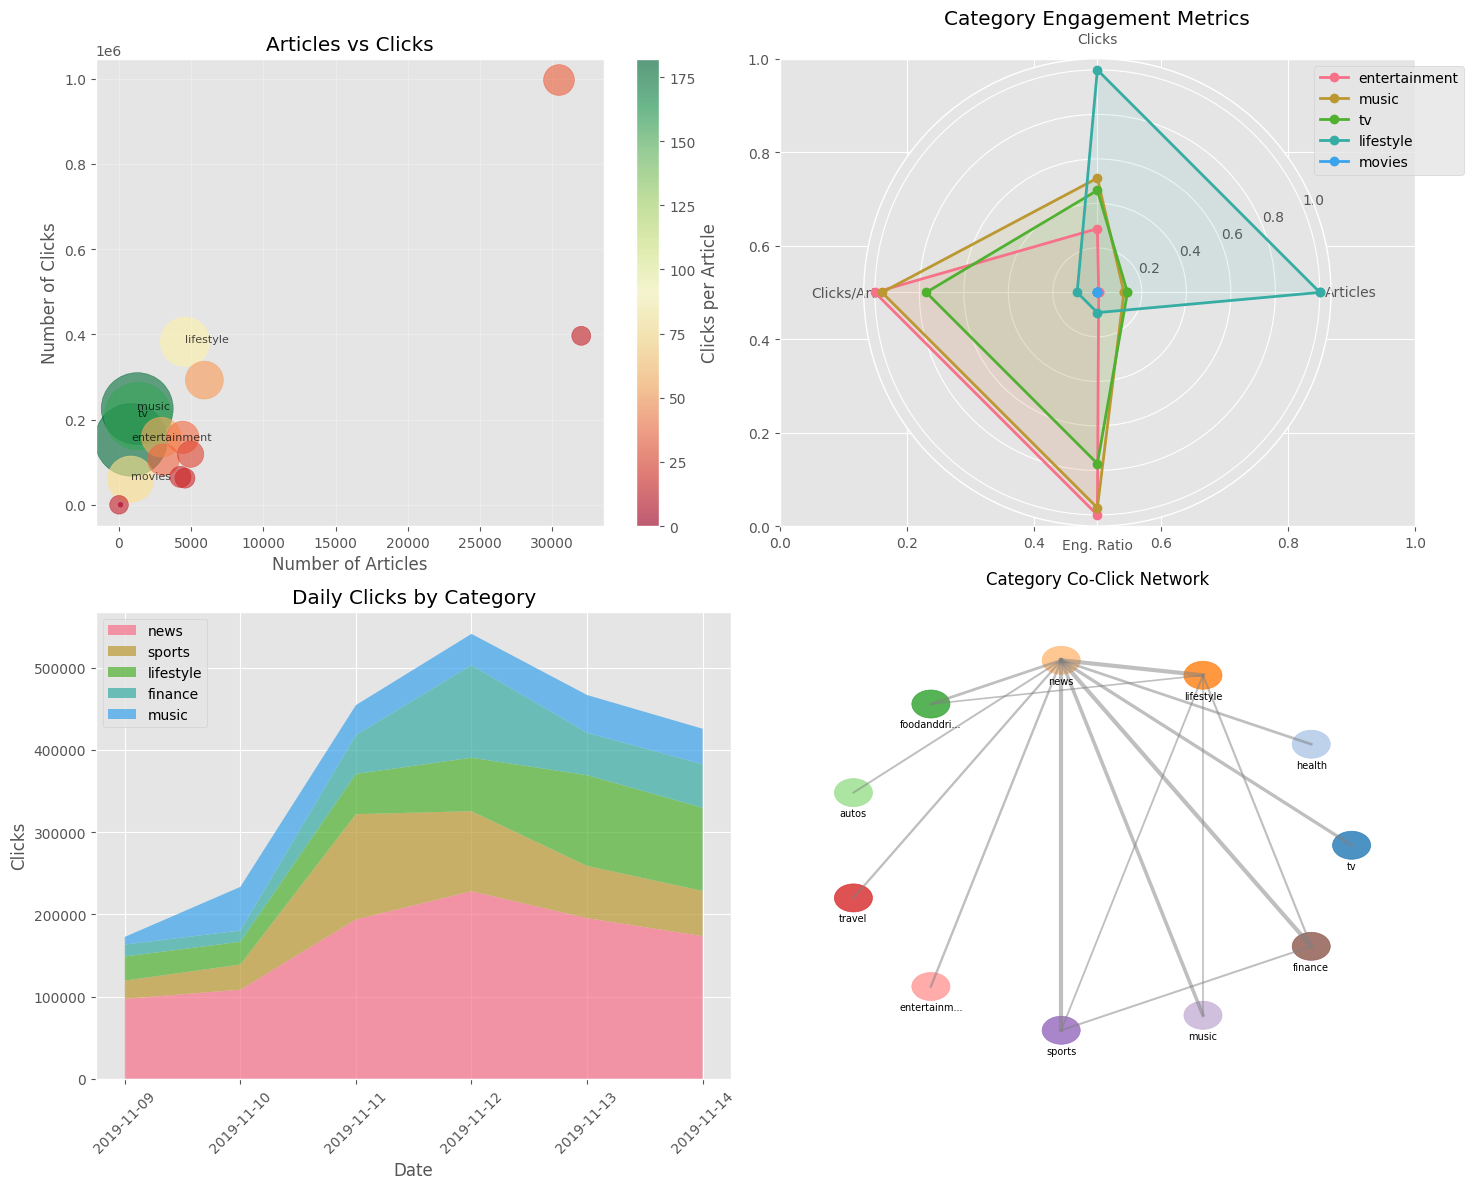

In [7]:
print("=" * 60)
print("INTEGRATED NEWS-BEHAVIOR ANALYSIS")
print("=" * 60)

click_data = []
for _, row in behaviors_df.iterrows():
    user_id = row['UserID']
    if row['Num_Clicks'] > 0:
        # Split impressions into news-click pairs
        for imp in row['Impressions'].split():
            if '-1' in imp:  # Only consider clicks
                news_id = imp.split('-')[0]
                click_data.append({
                    'UserID': user_id,
                    'NewsID': news_id,
                    'Click': 1
                })

if click_data:
    click_df = pd.DataFrame(click_data)
    print(f"Extracted {len(click_df):,} click events")
    
    # Merge with news data
    merged_df = pd.merge(click_df, 
                        news_df[['NewsID', 'Category', 'SubCategory', 'Title']], 
                        on='NewsID', how='left')
    
    # CATEGORY ENGAGEMENT ANALYSIS
    print("\n CATEGORY ENGAGEMENT ANALYSIS")
    print("-" * 40)
    
    category_clicks = merged_df['Category'].value_counts()
    category_articles = news_df['Category'].value_counts()
    
    engagement_df = pd.DataFrame({
        'Total_Articles': category_articles,
        'Total_Clicks': category_clicks
    }).fillna(0)
    
    engagement_df['Clicks_Per_Article'] = engagement_df['Total_Clicks'] / engagement_df['Total_Articles']
    engagement_df['Click_Share'] = engagement_df['Total_Clicks'] / engagement_df['Total_Clicks'].sum()
    engagement_df['Article_Share'] = engagement_df['Total_Articles'] / engagement_df['Total_Articles'].sum()
    engagement_df['Engagement_Ratio'] = engagement_df['Click_Share'] / engagement_df['Article_Share']
    
    engagement_df = engagement_df.sort_values('Clicks_Per_Article', ascending=False)
    
    print("\nTop 10 Categories by Engagement (Clicks per Article):")
    for i, (category, row) in enumerate(engagement_df.head(10).iterrows(), 1):
        print(f"{i:2d}. {category:20s}: {row['Clicks_Per_Article']:.3f} clicks/article "
              f"({int(row['Total_Clicks']):,} clicks, {int(row['Total_Articles']):,} articles)")
    
    # MOST POPULAR ARTICLES
    print("\n MOST POPULAR ARTICLES")
    print("-" * 40)
    
    article_clicks = click_df['NewsID'].value_counts().reset_index()
    article_clicks.columns = ['NewsID', 'Click_Count']
    
    top_articles = pd.merge(article_clicks.head(10), 
                           news_df[['NewsID', 'Title', 'Category']], 
                           on='NewsID', how='left')
    
    print("\nTop 10 Most Clicked Articles:")
    for i, row in top_articles.iterrows():
        title = row['Title'][:60] + '...' if len(row['Title']) > 60 else row['Title']
        print(f"\n{i+1}. {title}")
        print(f"   Category: {row['Category']}")
        print(f"   Clicks: {row['Click_Count']}")
    
    top_engagement = engagement_df.head(10)
    top_clicks = engagement_df.nlargest(10, 'Total_Clicks')
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # Scatter plot: Articles vs Clicks with size as engagement ratio
    scatter = axes[0, 0].scatter(engagement_df['Total_Articles'], 
                                engagement_df['Total_Clicks'],
                                s=engagement_df['Engagement_Ratio'] * 500,
                                alpha=0.6,
                                c=engagement_df['Clicks_Per_Article'],
                                cmap='RdYlGn')
    
    axes[0, 0].set_xlabel('Number of Articles')
    axes[0, 0].set_ylabel('Number of Clicks')
    axes[0, 0].set_title('Articles vs Clicks')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Add labels for top categories
    for idx, row in engagement_df.nlargest(5, 'Engagement_Ratio').iterrows():
        axes[0, 0].annotate(idx[:15], (row['Total_Articles'], row['Total_Clicks']),
                           fontsize=8, alpha=0.7)
    
    plt.colorbar(scatter, ax=axes[0, 0], label='Clicks per Article')
    
    # Radar chart for top categories engagement metrics
    top_5_cats = top_engagement.head(5).index.tolist()
    radar_metrics = ['Total_Articles', 'Total_Clicks', 'Clicks_Per_Article', 'Engagement_Ratio']
    
    # Normalize metrics for radar chart
    radar_data = engagement_df.loc[top_5_cats, radar_metrics]
    radar_normalized = radar_data.copy()
    for metric in radar_metrics:
        if radar_data[metric].max() > radar_data[metric].min():
            radar_normalized[metric] = (radar_data[metric] - radar_data[metric].min()) / (radar_data[metric].max() - radar_data[metric].min())
        else:
            radar_normalized[metric] = 0.5
    
    angles = np.linspace(0, 2 * np.pi, len(radar_metrics), endpoint=False).tolist()
    angles += angles[:1]  # Close the loop
    
    radar_ax = fig.add_subplot(222, polar=True)
    for i, cat in enumerate(top_5_cats):
        values = radar_normalized.loc[cat].values.tolist()
        values += values[:1]  # Close the loop
        radar_ax.plot(angles, values, 'o-', linewidth=2, label=cat[:15])
        radar_ax.fill(angles, values, alpha=0.1)
    
    radar_ax.set_xticks(angles[:-1])
    radar_ax.set_xticklabels(['Articles', 'Clicks', 'Clicks/Art', 'Eng. Ratio'])
    radar_ax.set_title('Category Engagement Metrics')
    radar_ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
    
    # Streamgraph for cumulative clicks over time
    if has_time_data and 'Time_Parsed' in behaviors_df.columns:
        # Merge time data with clicks
        time_click_data = []
        for _, row in behaviors_df[behaviors_df['Num_Clicks'] > 0].iterrows():
            for imp in row['Impressions'].split():
                if '-1' in imp:
                    news_id = imp.split('-')[0]
                    time_click_data.append({
                        'Time': row['Time_Parsed'],
                        'NewsID': news_id
                    })
        
        if time_click_data:
            time_click_df = pd.DataFrame(time_click_data)
            time_click_df['Date'] = time_click_df['Time'].dt.date
            time_click_df = pd.merge(time_click_df, news_df[['NewsID', 'Category']], 
                                    on='NewsID', how='left')
            
            # Get top 5 categories by clicks
            top_cats_clicks = time_click_df['Category'].value_counts().head(5).index.tolist()
            
            # Prepare data for streamgraph
            stream_data = []
            for date in sorted(time_click_df['Date'].unique()):
                date_data = {'Date': date}
                daily_clicks = time_click_df[time_click_df['Date'] == date]
                for cat in top_cats_clicks:
                    date_data[cat] = len(daily_clicks[daily_clicks['Category'] == cat])
                stream_data.append(date_data)
            
            stream_df = pd.DataFrame(stream_data).fillna(0)
            stream_df.set_index('Date', inplace=True)
            
            # Plot streamgraph
            axes[1, 0].stackplot(stream_df.index, 
                                [stream_df[cat] for cat in top_cats_clicks],
                                labels=[cat[:15] for cat in top_cats_clicks],
                                alpha=0.7)
            axes[1, 0].set_xlabel('Date')
            axes[1, 0].set_ylabel('Clicks')
            axes[1, 0].set_title('Daily Clicks by Category')
            axes[1, 0].legend(loc='upper left')
            axes[1, 0].tick_params(axis='x', rotation=45)
    
    else:
        axes[1, 0].text(0.5, 0.5, 'Time data not available\nfor streamgraph',
                       ha='center', va='center', fontsize=12)
        axes[1, 0].set_title('Daily Clicks by Category')
    
    # Network graph of category relationships based on co-clicks
    # Create category pairs from user click sequences
    category_pairs = []
    user_categories = merged_df.groupby('UserID')['Category'].apply(list)
    
    for categories in user_categories:
        if len(categories) > 1:
            for i in range(len(categories)):
                for j in range(i+1, len(categories)):
                    if categories[i] != categories[j]:
                        category_pairs.append(tuple(sorted([categories[i], categories[j]])))
    
    if category_pairs:
        from collections import Counter
        pair_counts = Counter(category_pairs)
        top_pairs = pair_counts.most_common(15)
        
        # Create network visualization
        axes[1, 1].axis('off')
        axes[1, 1].set_title('Category Co-Click Network', fontsize=12, pad=20)
        
        # Extract nodes and edges
        nodes = set()
        edges = []
        for (cat1, cat2), weight in top_pairs:
            nodes.add(cat1)
            nodes.add(cat2)
            edges.append((cat1, cat2, weight))
        
        nodes = list(nodes)
        node_positions = {}
        
        # Position nodes in a circle
        center_x, center_y = 0.5, 0.5
        radius = 0.4
        
        for i, node in enumerate(nodes):
            angle = 2 * np.pi * i / len(nodes)
            x = center_x + radius * np.cos(angle)
            y = center_y + radius * np.sin(angle)
            node_positions[node] = (x, y)
            
            # Draw node
            circle = plt.Circle((x, y), 0.03, color=plt.cm.tab20(i % 20), alpha=0.8)
            axes[1, 1].add_patch(circle)
            axes[1, 1].text(x, y - 0.05, node[:10] + '...' if len(node) > 10 else node,
                           fontsize=7, ha='center')
        
        # Draw edges
        for cat1, cat2, weight in edges:
            x1, y1 = node_positions[cat1]
            x2, y2 = node_positions[cat2]
            
            # Line width based on weight
            linewidth = min(weight / max(pair_counts.values()) * 5, 3)
            
            axes[1, 1].plot([x1, x2], [y1, y2], 'gray', 
                           alpha=0.5, linewidth=linewidth)
        
        axes[1, 1].set_xlim(0, 1)
        axes[1, 1].set_ylim(0, 1)
    
    else:
        axes[1, 1].text(0.5, 0.5, 'Insufficient data\nfor network graph',
                       ha='center', va='center', fontsize=12)
        axes[1, 1].set_title('Category Co-Click Network')
    
    plt.tight_layout()
    plt.show()

else:
    print("No click data available for integrated analysis")

  Categories like lifestyle and music achieve high engagement with relatively few articles, showing strong clicks per article. In contrast, entertainment has the most articles and clicks overall, but lower per-article engagement, indicating volume-driven performance.
  News acts as the central hub, frequently co-clicked with categories like sports, finance, and entertainment. This suggests users explore related topics in clusters, which supports cross-category recommendation strategies.

In [5]:
print("=" * 60)
print("KEY INSIGHTS SUMMARY")
print("=" * 60)

total_articles = len(news_df)
total_sessions = len(behaviors_df)
unique_users = behaviors_df['UserID'].nunique()
total_clicks = behaviors_df['Num_Clicks'].sum()
avg_impressions = behaviors_df['Num_Impressions'].mean() if 'Num_Impressions' in behaviors_df else 0
avg_clicks = behaviors_df['Num_Clicks'].mean() if 'Num_Clicks' in behaviors_df else 0
cold_start_pct = ((behaviors_df['History_Length'] == 0).sum() / total_sessions * 100
                  if 'History_Length' in behaviors_df else 0)
overall_ctr_pct = overall_ctr * 100 if 'overall_ctr' in globals() else 0

# News content metrics
title_word_avg = news_df['Title_Word_Count'].mean() if 'Title_Word_Count' in news_df else 0
abstract_word_avg = news_df['Abstract_Word_Count'].mean() if 'Abstract_Word_Count' in news_df else 0
unique_categories = news_df['Category'].nunique() if 'Category' in news_df else 0
unique_subcategories = news_df['SubCategory'].nunique() if 'SubCategory' in news_df else 0
title_entity_pct = ((news_df['Title_Entity_Count'] > 0).sum() / total_articles * 100
                    if 'Title_Entity_Count' in news_df else 0)

#Temporal metrics
peak_hour_str = f"{peak_hour}:00" if 'peak_hour' in globals() and has_time_data else "Time data not available"
peak_day_str = peak_day if 'peak_day' in globals() and has_time_data else "Time data not available"

summary_data = {
    'Dataset Overview': [
        f"Total news articles: {total_articles:,}",
        f"Total user sessions: {total_sessions:,}",
        f"Total unique users: {unique_users:,}",
        f"Total clicks recorded: {total_clicks:,}"
    ],
    'Content Characteristics': [
        f"Unique categories: {unique_categories}",
        f"Unique subcategories: {unique_subcategories}",
        f"Average title length: {title_word_avg:.1f} words",
        f"Average abstract length: {abstract_word_avg:.1f} words",
        f"Articles with entities: {title_entity_pct:.1f}%"
    ],
    'User Engagement': [
        f"Overall CTR: {overall_ctr_pct:.2f}%",
        f"Average impressions per session: {avg_impressions:.1f}",
        f"Average clicks per session: {avg_clicks:.1f}",
        f"Cold start sessions: {cold_start_pct:.1f}%"
    ],
    'Temporal Patterns (if available)': [
        f"Peak activity hour: {peak_hour_str}",
        f"Most active day: {peak_day_str}"
    ]
}

for category, insights in summary_data.items():
    print(f"\n{category}:")
    print("-" * 40)
    for insight in insights:
        print(f"  • {insight}")


KEY INSIGHTS SUMMARY

Dataset Overview:
----------------------------------------
  • Total news articles: 101,527
  • Total user sessions: 2,232,748
  • Total unique users: 711,222
  • Total clicks recorded: 3,383,656

Content Characteristics:
----------------------------------------
  • Unique categories: 18
  • Unique subcategories: 285
  • Average title length: 0.0 words
  • Average abstract length: 0.0 words
  • Articles with entities: 0.0%

User Engagement:
----------------------------------------
  • Overall CTR: 4.05%
  • Average impressions per session: 37.4
  • Average clicks per session: 1.5
  • Cold start sessions: 2.1%

Temporal Patterns (if available):
----------------------------------------
  • Peak activity hour: 11:00
  • Most active day: Tuesday
